# Fingerprint Enhancement — Gabor Filter Bank
**Project:** Signal & Image Processing Mini-Project  
**Method:** Multi-orientation Gabor filtering with morphological post-processing  
**Dataset:** FVC2000 DB1_B (`.tif` fingerprint images)

## Stage 1 — Import Libraries & Load Image

Image loaded. Shape: (374, 388), dtype: uint8


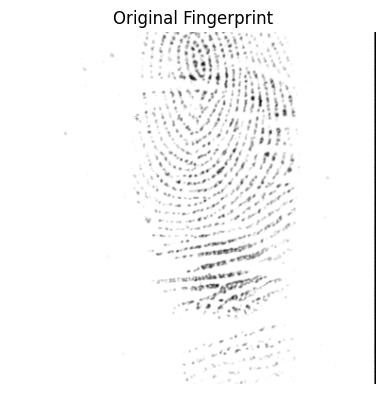

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

# ── Path: place fingerprints folder next to this notebook ──────────────────
IMAGE_PATH = os.path.join("fingerprints", "fingerprints", "DB1_B", "109_6.tif")

gray = cv.imread(IMAGE_PATH, cv.IMREAD_GRAYSCALE)

if gray is None:
    raise FileNotFoundError(
        f"Image not found at '{IMAGE_PATH}'. "
        "Make sure the 'fingerprints/DB1_B/' folder is in the same directory."
    )

print(f"Image loaded. Shape: {gray.shape}, dtype: {gray.dtype}")
plt.figure(figsize=(4, 4))
plt.imshow(gray, cmap='gray')
plt.title("Original Fingerprint")
plt.axis('off')
plt.tight_layout()
plt.show()


## Stage 2 — Noise Removal & Contrast Enhancement
Same preprocessing pipeline as the Canny notebook.  
After gamma correction, `cv.normalize` ensures the full [0, 255] range is used before Gabor filtering (called SMQT-normalisation in literature).

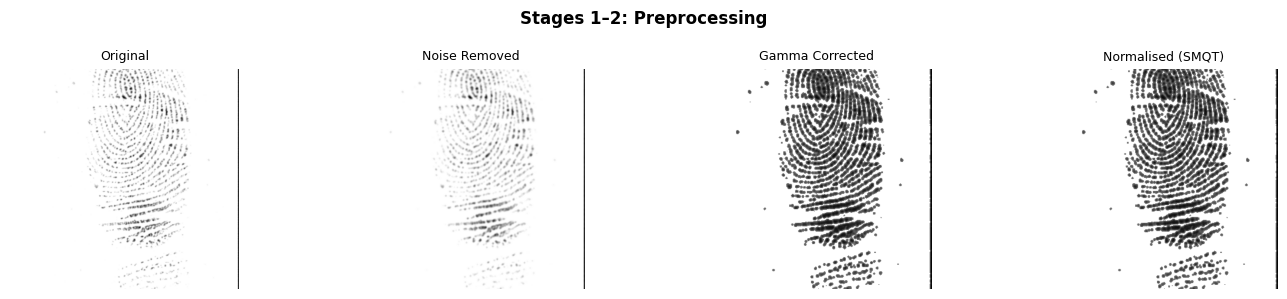

In [3]:
# ── Noise removal ──────────────────────────────────────────────────────────
median_filtered  = cv.medianBlur(gray, 3)
gaussian_filtered = cv.GaussianBlur(median_filtered, (3, 3), 0)

# ── Contrast enhancement ───────────────────────────────────────────────────
equalized = cv.equalizeHist(gaussian_filtered)
gamma     = 0.5
power_law = np.uint8(np.power(equalized / 255.0, gamma) * 255)

# ── Normalisation: stretch intensities to full [0, 255] range ──────────────
# This step (analogous to SMQT) ensures the Gabor filter has maximum dynamic range
smqt_stage = cv.normalize(power_law, None, 0, 255, cv.NORM_MINMAX)

plt.figure(figsize=(14, 3))
for i, (img, title) in enumerate([(gray, "Original"),
                                   (gaussian_filtered, "Noise Removed"),
                                   (power_law, "Gamma Corrected"),
                                   (smqt_stage, "Normalised (SMQT)")], 1):
    plt.subplot(1, 4, i)
    plt.imshow(img, cmap='gray')
    plt.title(title, fontsize=9)
    plt.axis('off')
plt.suptitle("Stages 1–2: Preprocessing", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Stage 3 — Gabor Filter Bank (8 Orientations)
A Gabor filter is a Gaussian modulated by a sinusoid.  
It responds strongly to ridges aligned with its orientation (θ).  
By sweeping θ from 0° to 157.5° in steps of 22.5°, we capture all ridge directions.  

**Parameters:**
- `ksize=15` — kernel size (larger = more frequency resolution)
- `sigma=1.0` — standard deviation of the Gaussian envelope
- `lamda=0.5` — wavelength of the sinusoidal component
- `gamma=0.5` — spatial aspect ratio
- `phi=2`    — phase offset

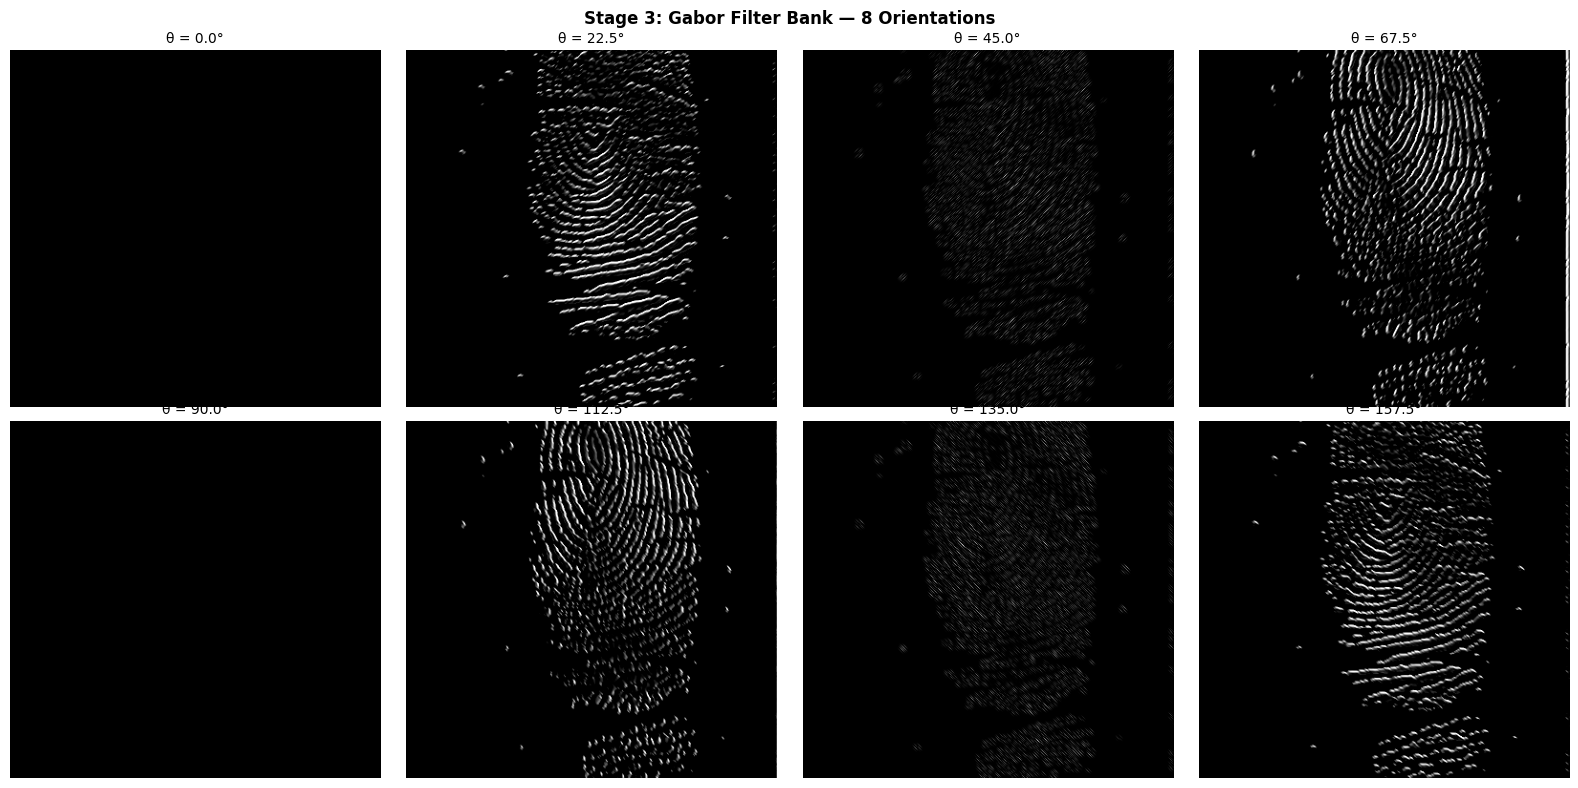

Generated 8 Gabor responses.


In [4]:
# ── Gabor filter parameters ────────────────────────────────────────────────
ksize = 15    # kernel size
sigma = 1.0   # Gaussian envelope width
lamda = 0.5   # sinusoidal wavelength — controls ridge frequency response
gamma_g = 0.5 # spatial aspect ratio (ellipticity of the filter)
phi   = 2     # phase offset

# Generate 8 evenly spaced angles from 0° to 157.5°
thetas = np.arange(0, np.pi, np.pi / 8)

gabor_outputs = []

plt.figure(figsize=(16, 8))

for i, theta in enumerate(thetas):
    # Build the Gabor kernel for this orientation
    gabor_kernel = cv.getGaborKernel(
        (ksize, ksize), sigma, theta, lamda, gamma_g, phi, ktype=cv.CV_32F
    )
    # Convolve the normalised image with this kernel
    gabor_response = cv.filter2D(smqt_stage, cv.CV_8U, gabor_kernel)
    gabor_outputs.append(gabor_response)

    plt.subplot(2, 4, i + 1)
    plt.imshow(gabor_response, cmap='gray')
    plt.title(f"θ = {np.degrees(theta):.1f}°", fontsize=10)
    plt.axis('off')

plt.suptitle("Stage 3: Gabor Filter Bank — 8 Orientations", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Generated {len(gabor_outputs)} Gabor responses.")


## Stage 4 — Max-Fusion across All Orientations
Taking the **pixel-wise maximum** across all 8 filter responses retains the strongest ridge signal at each location, regardless of local orientation.

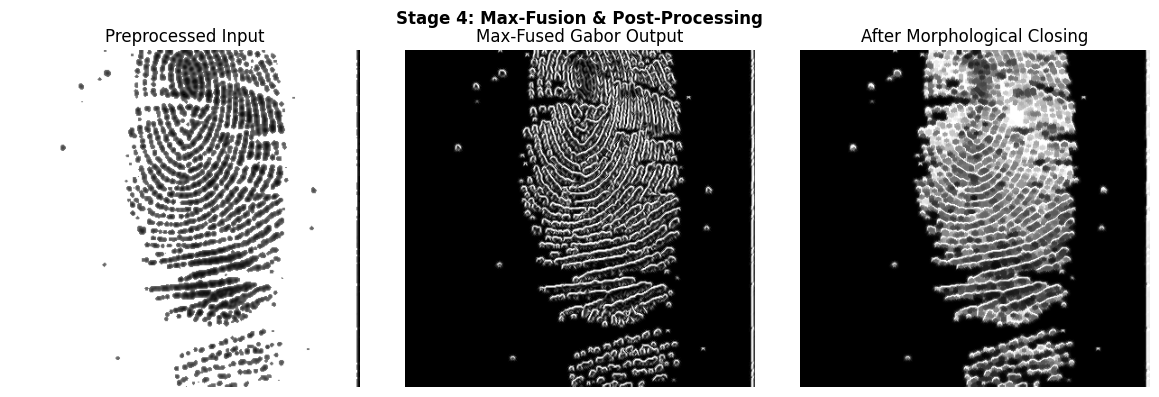

In [5]:
# Stack all Gabor responses into a 3-D array and take the max across the orientation axis
gabor_stack = np.array(gabor_outputs)            # shape: (8, H, W)
final_max   = np.max(gabor_stack, axis=0)        # shape: (H, W)

# Morphological closing: joins small gaps in ridge continuity
# A 5×5 elliptical kernel handles moderately wide gaps
kernel_large = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
fused_closed = cv.morphologyEx(final_max, cv.MORPH_CLOSE, kernel_large)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(smqt_stage, cmap='gray')
plt.title("Preprocessed Input")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(final_max, cmap='gray')
plt.title("Max-Fused Gabor Output")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(fused_closed, cmap='gray')
plt.title("After Morphological Closing")
plt.axis('off')

plt.suptitle("Stage 4: Max-Fusion & Post-Processing", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Stage 5 — Selective Angle Combination (22.5° + 67.5°)
For many fingerprints, the dominant ridge directions are diagonal. Combining the 22.5° and 67.5° Gabor responses with equal weights often produces a cleaner result than the full 8-way max-fusion.

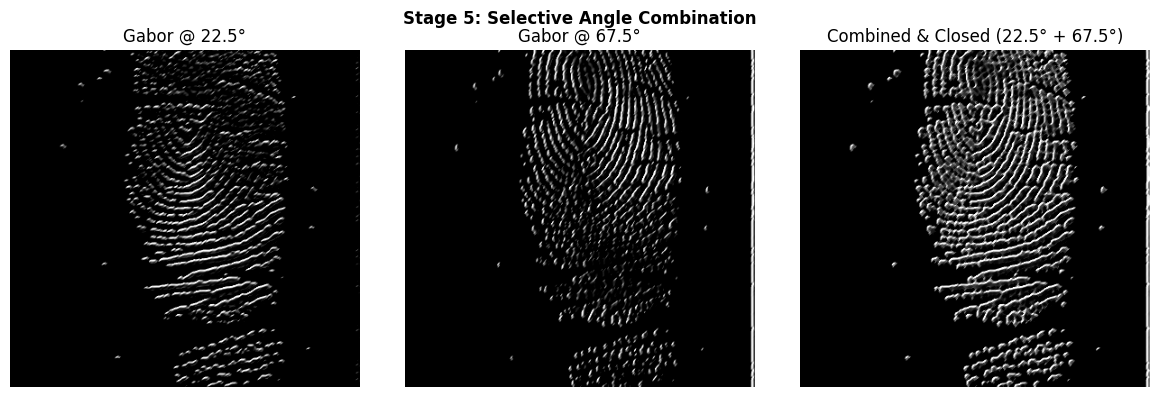

In [6]:
# index 1 = 22.5°,  index 3 = 67.5°
res_22 = gabor_outputs[1]
res_67 = gabor_outputs[3]

# Weighted addition (equal weights)
combined = cv.addWeighted(res_22, 1.0, res_67, 1.0, 0)

# Closing to join ridge segments
kernel_close = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))
joined = cv.morphologyEx(combined, cv.MORPH_CLOSE, kernel_close)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(res_22, cmap='gray')
plt.title("Gabor @ 22.5°")
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(res_67, cmap='gray')
plt.title("Gabor @ 67.5°")
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(joined, cmap='gray')
plt.title("Combined & Closed (22.5° + 67.5°)")
plt.axis('off')
plt.suptitle("Stage 5: Selective Angle Combination", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Summary: Max-Fusion vs Selective Combination

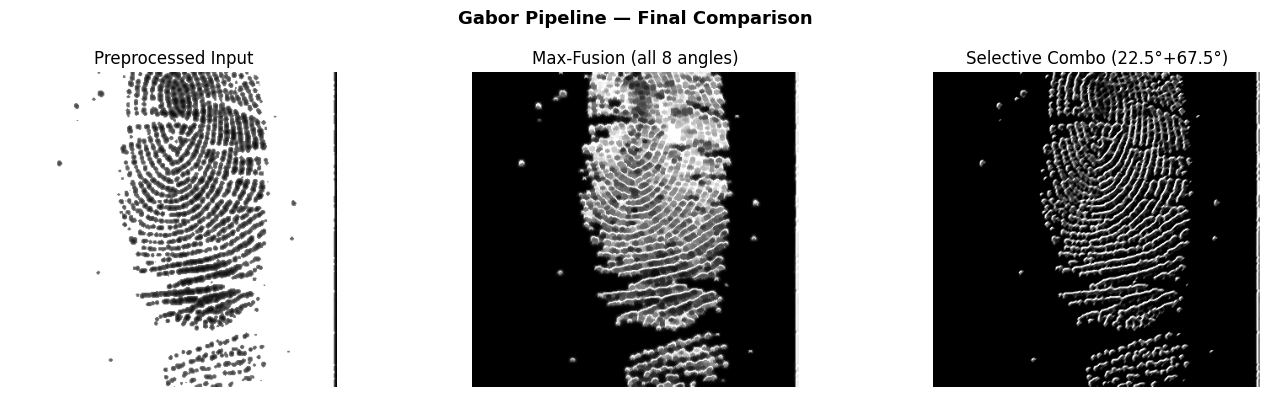

In [7]:
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.imshow(smqt_stage, cmap='gray')
plt.title("Preprocessed Input")
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(fused_closed, cmap='gray')
plt.title("Max-Fusion (all 8 angles)")
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(joined, cmap='gray')
plt.title("Selective Combo (22.5°+67.5°)")
plt.axis('off')
plt.suptitle("Gabor Pipeline — Final Comparison", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
